# What you need to do:
## Data Preparation

- Load and merge pokemon.csv and combats.csv.
- Fix missing values:
    1. Fill the missing Name for Pokemon #62 (Primeape).
    2. Handle NaN values in Type 2 (mark as “None” if missing).
- calculate each Pokemon’s win percentage using the combat data.


In [ ]:
import pandas as pd
df_pokemon = pd.read_csv('Pokemon Data Analysis Tutorial/pokemon.csv')
df_pokemon.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [9]:
df_pokemon[(df_pokemon['Name'].isnull())]
df_pokemon.loc[df_pokemon['#'] == 63, 'Name'] = 'Primeape'
df_pokemon['Type 2'] = df_pokemon['Type 2'].fillna("None")
df_pokemon.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      800 non-null    str  
 4   HP          800 non-null    int64
 5   Attack      800 non-null    int64
 6   Defense     800 non-null    int64
 7   Sp. Atk     800 non-null    int64
 8   Sp. Def     800 non-null    int64
 9   Speed       800 non-null    int64
 10  Generation  800 non-null    int64
 11  Legendary   800 non-null    bool 
dtypes: bool(1), int64(8), str(3)
memory usage: 69.7 KB


In [2]:
df_combat = pd.read_csv('Pokemon Data Analysis Tutorial/combats.csv')
df_combat.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


In [4]:
df_combat.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   50000 non-null  int64
 1   Second_pokemon  50000 non-null  int64
 2   Winner          50000 non-null  int64
dtypes: int64(3)
memory usage: 1.1 MB


In [24]:
total_battles = pd.concat([df_combat['First_pokemon'], df_combat['Second_pokemon']]).value_counts()
# print(total_battles.head())

# Count total wins each pokemon had
total_wins = df_combat['Winner'].value_counts()
# print(total_wins.head())

win_pct = (total_wins / total_battles * 100).fillna(0)
# print(win_pct.head())

df_pokemon['win_pct'] = df_pokemon['#'].map(win_pct).fillna(0).round(2)
df_pokemon.head(10)



,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,win_pct
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,27.82
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,38.02
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,67.42
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,56.00
4,5,Charmander,Fire,None,39,52,43,60,50,65,1,False,49.11
5,6,Charmeleon,Fire,None,58,64,58,80,65,80,1,False,54.24
6,7,Charizard,Fire,Flying,78,84,78,109,85,100,1,False,86.47
7,8,Mega Charizard X,Fire,Dragon,78,130,111,130,85,100,1,False,85.61
8,9,Mega Charizard Y,Fire,Flying,78,104,78,159,115,100,1,False,84.44
9,10,Squirtle,Water,None,44,48,65,50,64,43,1,False,16.24


## Exploratory Analysis & Visualization

- Create a correlation matrix to identify relationships between stats (HP, Attack, Speed) and win percentage.
- Plot a Seaborn pairplot or PairGrid for stats vs. win percentage.
- Analyze the top 10 Pokemon by win percentage and their stats.

           HP  Attack  Defense  Speed  Sp. Atk  Sp. Def  win_pct
HP       1.00    0.42     0.24   0.18     0.36     0.38     0.23
Attack   0.42    1.00     0.44   0.38     0.40     0.26     0.48
Defense  0.24    0.44     1.00   0.02     0.22     0.51     0.11
Speed    0.18    0.38     0.02   1.00     0.47     0.26     0.91
Sp. Atk  0.36    0.40     0.22   0.47     1.00     0.51     0.46
Sp. Def  0.38    0.26     0.51   0.26     0.51     1.00     0.29
win_pct  0.23    0.48     0.11   0.91     0.46     0.29     1.00


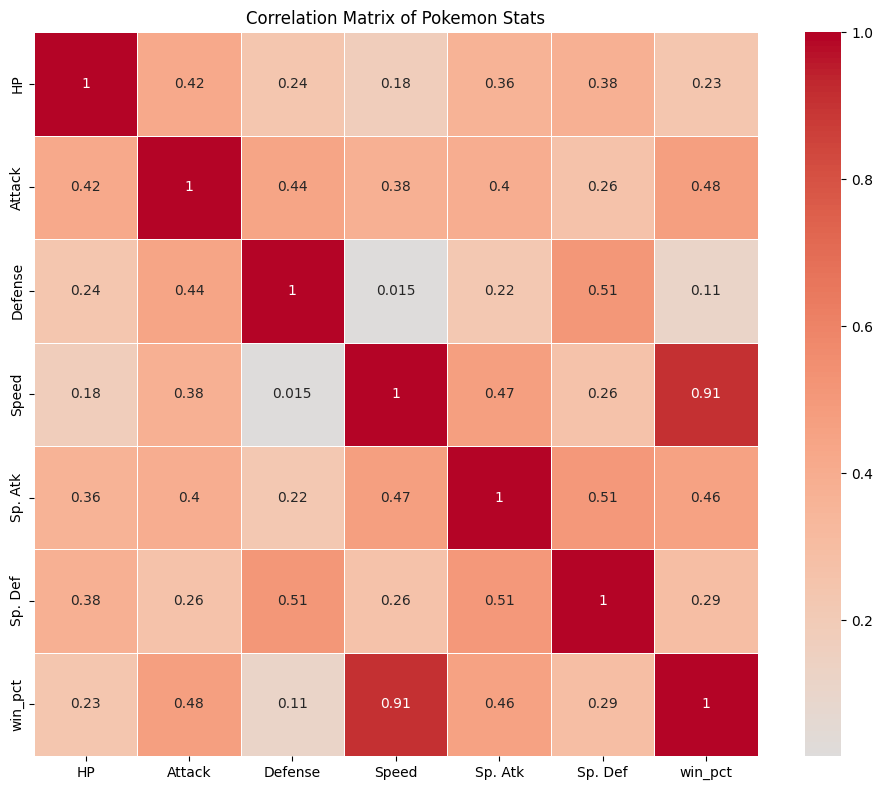

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 8))
# Calculate correlation matrix:
cols = ['HP', 'Attack', 'Defense', 'Speed', 'Sp. Atk',	'Sp. Def', 'win_pct']

correlation_matrix = df_pokemon[cols].corr()
print(correlation_matrix.round(2))

# Create heatmap:
# TODO: Use sns.heatmap() with parameters: annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,square=True, linewidths=0.5)

plt.title('Correlation Matrix of Pokemon Stats')
plt.tight_layout()
plt.show()

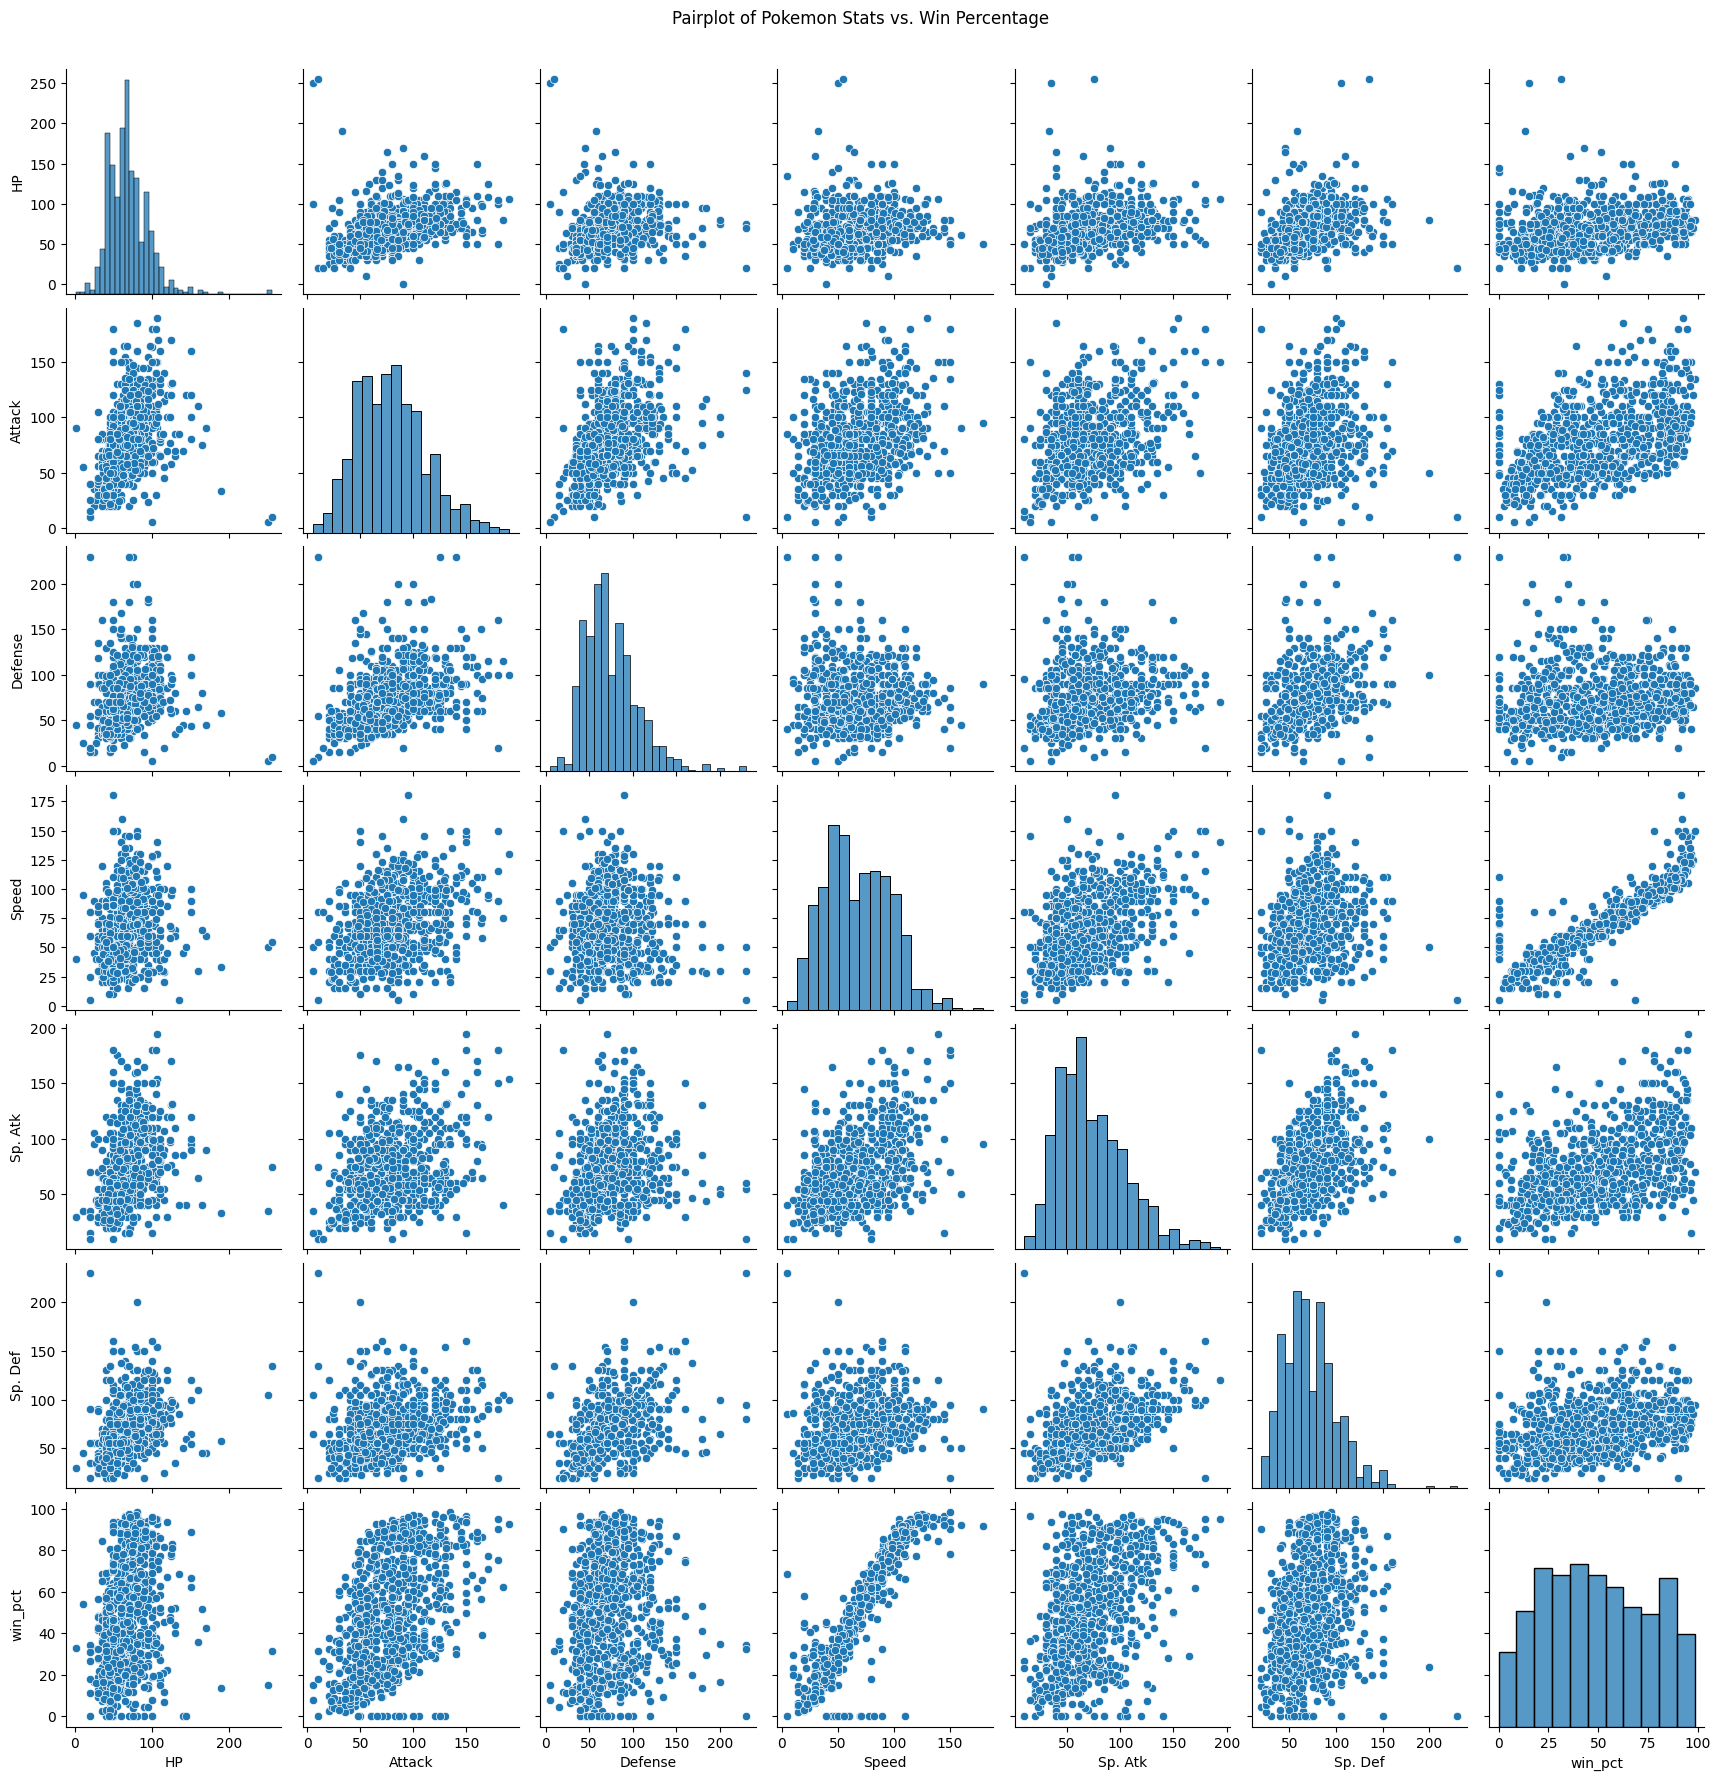

In [26]:
sns.pairplot(df_pokemon[cols])
plt.suptitle('Pairplot of Pokemon Stats vs. Win Percentage', y=1.02)
plt.show()

In [31]:
top10 = df_pokemon.sort_values('win_pct', ascending=False).head(10)
top10

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,win_pct
154,155,Mega Aerodactyl,Rock,Flying,80,135,85,70,95,150,1,False,98.45
512,513,Weavile,Dark,Ice,70,120,65,45,85,125,4,False,97.48
703,704,Tornadus Therian Forme,Flying,None,79,100,80,110,90,121,5,True,96.80
19,20,Mega Beedrill,Bug,Poison,65,150,40,15,80,145,1,False,96.64
153,154,Aerodactyl,Rock,Flying,80,105,65,60,75,130,1,False,96.45
476,477,Mega Lopunny,Normal,Fighting,65,136,94,54,96,135,4,False,96.12
726,727,Greninja,Water,Dark,72,95,67,103,71,122,6,False,96.06
716,717,Meloetta Pirouette Forme,Normal,Fighting,100,128,90,77,77,128,5,False,95.93
164,165,Mega Mewtwo Y,Psychic,None,106,150,70,194,120,140,1,True,95.20
349,350,Mega Sharpedo,Water,Dark,70,140,70,110,65,105,3,False,95.00


In [38]:
# To see how their average stats compare to the overall population:
stats_cols = cols[:-1]
print(stats_cols)

print("Top 10 average stats:")
print(top10[stats_cols].mean())
print("\nOverall average stats:")
print(df_pokemon[stats_cols].mean())



['HP', 'Attack', 'Defense', 'Speed', 'Sp. Atk', 'Sp. Def']
Top 10 average stats:
HP          78.7
Attack     125.9
Defense     72.6
Speed      130.1
Sp. Atk     83.8
Sp. Def     85.4
dtype: float64

Overall average stats:
HP         69.25875
Attack     79.00125
Defense    73.84250
Speed      68.27750
Sp. Atk    72.82000
Sp. Def    71.90250
dtype: float64


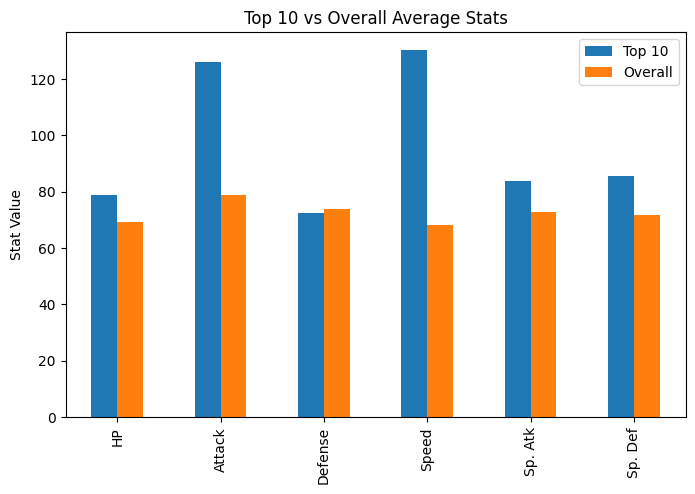

In [39]:
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    'Top 10': top10[stats_cols].mean(),
    'Overall': df_pokemon[stats_cols].mean()
})
comparison.plot(kind='bar', figsize=(8,5), title='Top 10 vs Overall Average Stats')
plt.ylabel('Stat Value')
plt.show()

In [ ]:
print('From the chart, we notice top10 has average higher HP, Attack, Speed, Sp.Attack, Sp.Defense than overall average.')
print('Attach and Speed are significantly higher than average overall population. We can make pre assumption that these 2 factors have more significant impacts on winning a battle.')

From the chart, we notice top10 has average higher HP, Attack, Speed, Sp.Attack, Sp.Defense than overall average.
 Attach and Speed are significantly higher than average overall population. We can make pre assumption that these 2 factors have more significant impacts on winning a battle.


## Machine Learning

- Split data into training/testing sets (80/20 split).
- Train and evaluate 3 regression models (e.g., Linear Regression, Random Forest, XGBoost) to predict win percentage.
- Compare model performance using Mean Absolute Error (MAE).

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Features and target
drop_cols = ['#', 'Name', 'win_pct']

y = df_pokemon['win_pct']
X = df_pokemon.drop(columns=drop_cols)

# One-hot encode categorical columns (Type 1, Type 2, and Legendary if it's bool/categorical)
X = pd.get_dummies(X, columns=['Type 1', 'Type 2'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

result = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred) # TODO: Calculate R² score

    result[name] = mae
    print(f'{name}: MAE = {mae:.2f}')
    print(f'{name}: r2 = {r2:.2f}')
    
    
results_df = pd.Series(result, name='MAE').sort_values()
results_df



Linear Regression: MAE = 6.14
Linear Regression: r2 = 0.85
Random Forest: MAE = 5.68
Random Forest: r2 = 0.86
XGBoost: MAE = 6.08
XGBoost: r2 = 0.85


Random Forest        5.677184
XGBoost              6.077629
Linear Regression    6.142257
Name: MAE, dtype: float64